# Flow Matching Project Report Notebook

This notebook is the **report itself**: it runs all experiments, displays all plots/tables, and includes text interpretation blocks.

> You can add your own final wording directly under each interpretation section.


## 1. Project Scope

### Goal
- Reproduce baseline comparison between diffusion-like and OT-like flow-matching paths.
- Extend analysis with trajectory geometry and solver-efficiency diagnostics.

### Variants compared
- `ot`: ExactOptimalTransportConditionalFlowMatcher
- `vp`: VariancePreservingConditionalFlowMatcher
- `target`: TargetConditionalFlowMatcher
- `schrodinger`: SchrodingerBridgeConditionalFlowMatcher

### What is new in this project
- Curvature/alignment/speed trajectory diagnostics
- Curvature-error per-sample correlation
- True NFE-budget comparison across solvers (Euler/Heun/RK4)
- Time-to-structure curves and AUC summary


In [20]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from fm_project.config import ExperimentConfig
from fm_project.experiments import run_full_experiment

ROOT


PosixPath('/Users/sleider/ml/flow_matching_project')

## 2. Experiment Configuration

Adjust this cell if needed before running (dataset, epochs, etc.).


In [21]:
cfg = ExperimentConfig(
    dataset_name='checkerboard',
    n_epochs=200,
    steps_per_epoch=50,
    n_train=20000,
    n_eval=5000,
    batch_size=512,
    seed=42,
    device='cpu',
    output_dir=str(ROOT / 'results'),
)
cfg


ExperimentConfig(dataset_name='checkerboard', n_train=20000, n_eval=5000, batch_size=512, hidden_dim=256, time_dim=64, n_layers=3, lr=0.001, n_epochs=200, steps_per_epoch=50, weight_decay=0.0, sigma=0.1, nfe_list=[8, 16, 32, 64, 128], solver_methods=['euler', 'heun', 'rk4'], seed=42, device='cpu', output_dir='/Users/sleider/ml/flow_matching_project/results', variants={'ot': 'ExactOptimalTransportConditionalFlowMatcher', 'vp': 'VariancePreservingConditionalFlowMatcher', 'target': 'TargetConditionalFlowMatcher', 'schrodinger': 'SchrodingerBridgeConditionalFlowMatcher'})

## 3. Run Full Pipeline

This executes training + all experiments + figure generation.


In [22]:
results = run_full_experiment(cfg)
sorted(results.keys())


['config',
 'curvature_error_corr',
 'device',
 'main_metrics',
 'nfe_mmd',
 'nfe_summary',
 'nfe_swd',
 'progress_auc_swd',
 'scorecard',
 'solver_nfe_swd',
 'training_history',
 'trajectory_metrics']

In [23]:
import json
from pathlib import Path

res_path = Path(cfg.output_dir) / 'results.json'
with open(res_path, 'r', encoding='utf-8') as f:
    results = json.load(f)

print('Loaded:', res_path)
print('Device used:', results.get('device'))
print('Keys:', sorted(results.keys()))


Loaded: /Users/sleider/ml/flow_matching_project/results/results.json
Device used: cpu
Keys: ['config', 'curvature_error_corr', 'device', 'main_metrics', 'nfe_mmd', 'nfe_summary', 'nfe_swd', 'progress_auc_swd', 'scorecard', 'solver_nfe_swd', 'training_history', 'trajectory_metrics']


## Expected Results (Before Interpretation)

These are the expected trends for this project:
- OT/SB variants are typically strongest at low-to-moderate NFE.
- VP usually improves more when NFE increases.
- Lower trajectory curvature often helps low-NFE robustness.
- Solver ranking is usually more stable with Heun/RK4 than Euler at low budget.
- Better paths should show lower time-to-structure AUC.

The next cell auto-generates an **Observed vs Expected** summary from `results.json`.


In [24]:
import pandas as pd

mm = pd.DataFrame(results['main_metrics']).T
best_swd = mm['SWD@64'].idxmin()
best_mmd = mm['MMD@64'].idxmin()
low_nfe_col = 'SWD_low_nfe'
ns = pd.DataFrame(results['nfe_summary']).T
best_low_nfe = ns[low_nfe_col].idxmin()
tm = pd.DataFrame(results['trajectory_metrics']).T
lowest_curv = tm['curvature_mean'].idxmin()
auc = pd.Series(results.get('progress_auc_swd', {}))
best_auc = auc.idxmin() if len(auc) else 'n/a'
corr = pd.Series(results.get('curvature_error_corr', {}))

summary = pd.DataFrame({
    'best_SWD@64': [best_swd],
    'best_MMD@64': [best_mmd],
    'best_lowNFE_SWD': [best_low_nfe],
    'lowest_curvature': [lowest_curv],
    'best_time_to_structure_auc': [best_auc],
})
display(summary)

print('Curvature-error correlations (per variant):')
display(corr.to_frame('corr'))

print('Quick expected-vs-observed notes:')
print(f'- Best SWD@64: {best_swd} (expected often OT/SB)')
print(f'- Best low-NFE SWD: {best_low_nfe} (expected often OT/SB)')
print(f'- Lowest curvature: {lowest_curv} (expected often OT/SB)')
if len(auc):
    print(f'- Best time-to-structure AUC: {best_auc} (lower is better)')
print('- Correlation signs can vary with dataset/seed; interpret with caution.')


,best_SWD@64,best_MMD@64,best_lowNFE_SWD,lowest_curvature,best_time_to_structure_auc
0,schrodinger,schrodinger,schrodinger,ot,target


Curvature-error correlations (per variant):


,corr
ot,-0.038138
vp,-0.260514
target,-0.028285
schrodinger,-0.023667


Quick expected-vs-observed notes:
- Best SWD@64: schrodinger (expected often OT/SB)
- Best low-NFE SWD: schrodinger (expected often OT/SB)
- Lowest curvature: ot (expected often OT/SB)
- Best time-to-structure AUC: target (lower is better)
- Correlation signs can vary with dataset/seed; interpret with caution.


## 4. Experiment A — Training Dynamics

This experiment compares training curves across variants.

### Expected Results (A)
- All variants should show decreasing normalized loss.
- OT/SB are often smoother and stabilize earlier.
- Raw losses may differ in scale and are not directly comparable across variants.

### Interpretation guide
- Use **normalized loss** for cross-variant fairness.
- Raw loss can differ because target velocity scales differ across matchers.


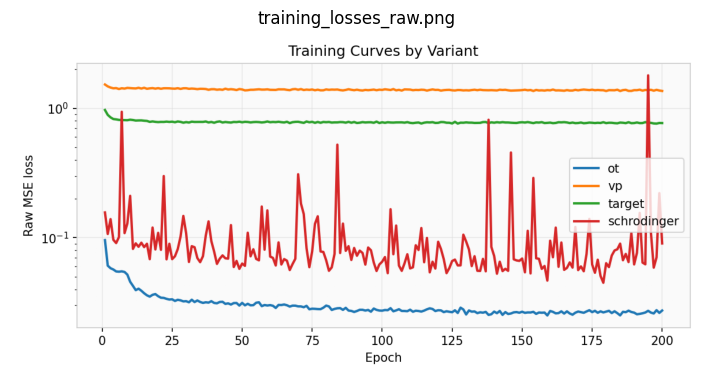

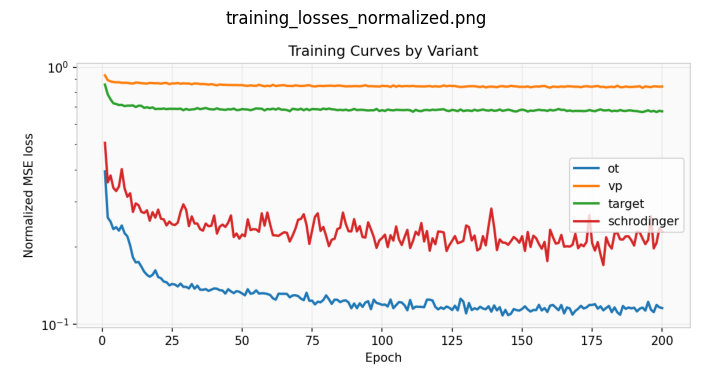

In [25]:
import matplotlib.pyplot as plt
from matplotlib.image import imread

fig_dir = Path(cfg.output_dir) / 'figures'

for name in ['training_losses_raw.png', 'training_losses_normalized.png']:
    p = fig_dir / name
    if p.exists():
        plt.figure(figsize=(10, 4.5))
        plt.imshow(imread(p))
        plt.axis('off')
        plt.title(name)
        plt.show()
    else:
        print('Missing figure:', p)


### Your Notes (A)
Write your interpretation here:
- Which variant converges fastest?
- Which curve is most stable?


## 5. Experiment B — Sample Quality at Reference NFE

This section shows sample grids and final quality metrics (`SWD@64`, `MMD@64`).

### Expected Results (B)
- OT/SB are typically among the best at moderate NFE.
- VP may be competitive but usually benefits from larger NFE.
- SWD and MMD rankings are often similar but not always identical.


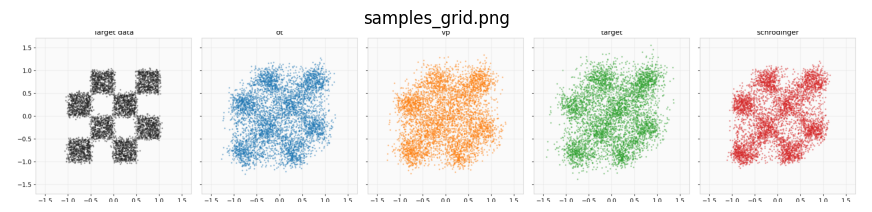

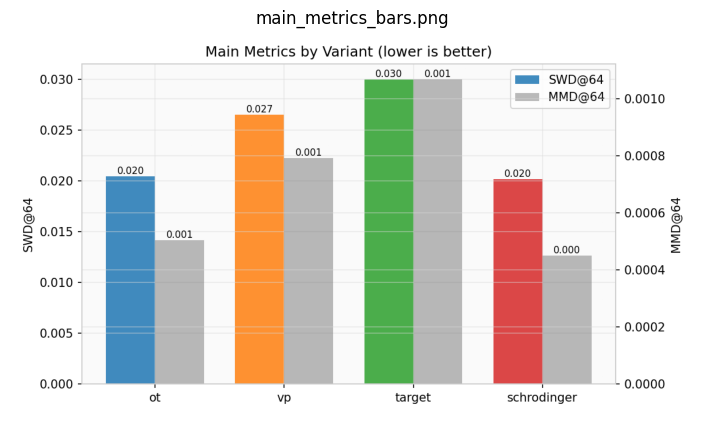

In [26]:
for name in ['samples_grid.png', 'main_metrics_bars.png']:
    p = fig_dir / name
    if p.exists():
        plt.figure(figsize=(11, 5))
        plt.imshow(imread(p))
        plt.axis('off')
        plt.title(name)
        plt.show()
    else:
        print('Missing figure:', p)


In [27]:
import pandas as pd

main_metrics_df = pd.DataFrame(results['main_metrics']).T.sort_index()
main_metrics_df


,SWD@64,MMD@64
ot,0.020488,0.000503
schrodinger,0.020155,0.000449
target,0.030040,0.001068
vp,0.026546,0.000792


### Your Notes (B)
Write your interpretation here:
- Best variant at NFE=64 according to SWD?
- Is MMD ranking consistent with SWD ranking?


## 6. Experiment C — Compute/Quality Tradeoff (NFE)

This evaluates quality under different NFE budgets.

### Expected Results (C)
- All methods improve as NFE increases.
- OT/SB should degrade less at low NFE.
- Gaps may shrink at high NFE when discretization error is reduced.


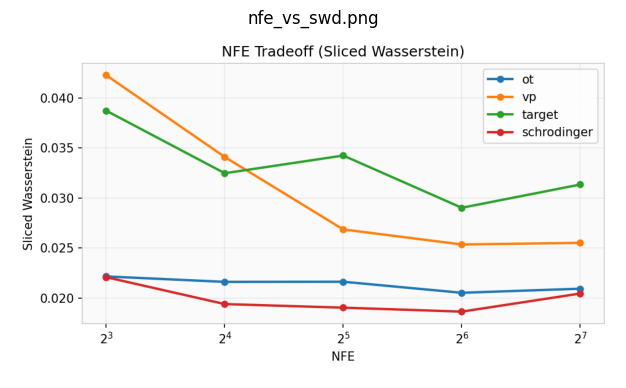

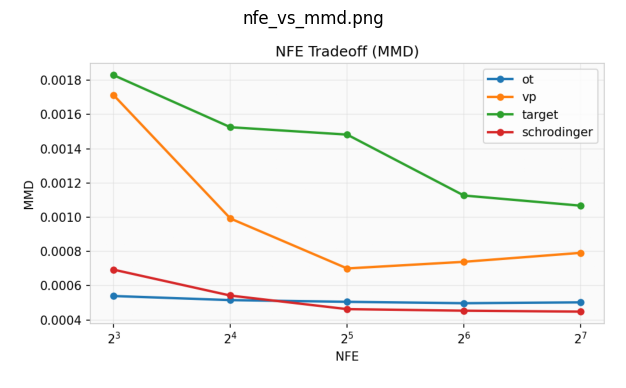

In [28]:
for name in ['nfe_vs_swd.png', 'nfe_vs_mmd.png']:
    p = fig_dir / name
    if p.exists():
        plt.figure(figsize=(9, 4.5))
        plt.imshow(imread(p))
        plt.axis('off')
        plt.title(name)
        plt.show()
    else:
        print('Missing figure:', p)


In [29]:
nfe_summary_df = pd.DataFrame(results['nfe_summary']).T.sort_index()
nfe_summary_df


,SWD_low_nfe,SWD_high_nfe,MMD_low_nfe,MMD_high_nfe
ot,0.022177,0.020953,0.000540,0.000503
schrodinger,0.022103,0.020473,0.000694,0.000449
target,0.038714,0.031348,0.001830,0.001068
vp,0.042255,0.025526,0.001713,0.000792


### Your Notes (C)
Write your interpretation here:
- Which variant is strongest at low NFE?
- Does ranking change at high NFE?


## 7. Experiment D — Trajectory Geometry

This section reports trajectory geometry metrics and their relation to low-NFE error.

### Expected Results (D)
- OT/SB should have lower average curvature than VP/Target in many runs.
- Straighter trajectories should be associated with better low-NFE robustness.
- Correlation can be weak/noisy depending on seed and dataset.


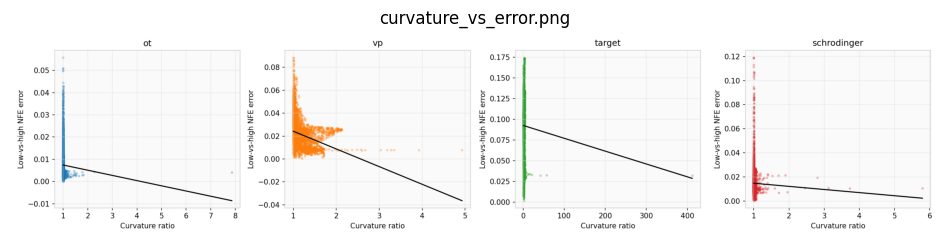

In [30]:
for name in ['curvature_vs_error.png']:
    p = fig_dir / name
    if p.exists():
        plt.figure(figsize=(12, 4.5))
        plt.imshow(imread(p))
        plt.axis('off')
        plt.title(name)
        plt.show()
    else:
        print('Missing figure:', p)


In [31]:
traj_df = pd.DataFrame(results['trajectory_metrics']).T.sort_index()
corr_df = pd.DataFrame({'curvature_error_corr': results['curvature_error_corr']}).T
display(traj_df)
display(corr_df)


,curvature_mean,curvature_std,speed_mean,alignment_mean
ot,1.005853,0.057518,0.007888,0.994917
schrodinger,1.010156,0.079035,0.008032,0.991082
target,1.750658,1.361313,0.010712,0.574286
vp,1.150823,0.210799,0.008325,0.828055


,ot,vp,target,schrodinger
curvature_error_corr,-0.038138,-0.260514,-0.028285,-0.023667


### Your Notes (D)
Write your interpretation here:
- Which variants have straighter trajectories (lower curvature)?
- Is curvature-error correlation strong/weak and in which direction?


## 8. Experiment E — Solver Robustness at Equal NFE Budget

Compares Euler/Heun/RK4 fairly under equal function-evaluation budgets.

### Expected Results (E)
- Heun/RK4 should be more stable than Euler at very low NFE.
- Relative ranking of variants should be more reliable under higher-order solvers.
- OT/SB are expected to remain strong under solver changes.


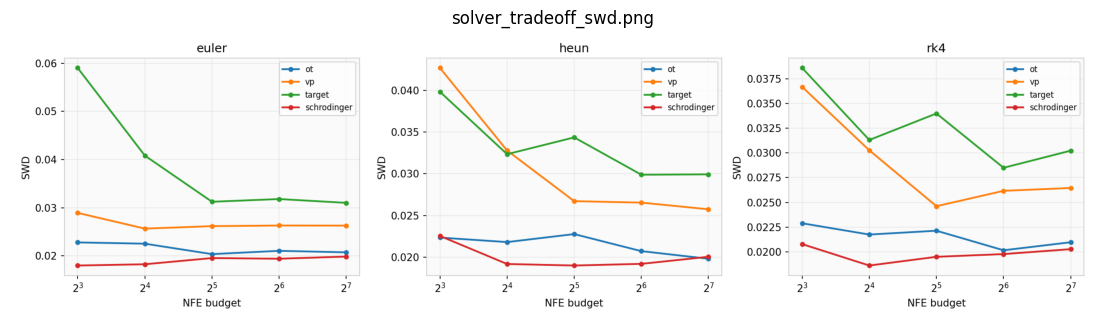

In [32]:
for name in ['solver_tradeoff_swd.png']:
    p = fig_dir / name
    if p.exists():
        plt.figure(figsize=(14, 5))
        plt.imshow(imread(p))
        plt.axis('off')
        plt.title(name)
        plt.show()
    else:
        print('Missing figure:', p)


In [33]:
# Flatten nested solver result for readability
solver_rows = []
for method, per_variant in results.get('solver_nfe_swd', {}).items():
    for variant, nfe_map in per_variant.items():
        for nfe, swd in nfe_map.items():
            solver_rows.append({'method': method, 'variant': variant, 'nfe': int(nfe), 'swd': float(swd)})

solver_df = pd.DataFrame(solver_rows)
solver_df.sort_values(['method', 'variant', 'nfe']).head(30)


,method,variant,nfe,swd
0,euler,ot,8,0.022812
1,euler,ot,16,0.022547
2,euler,ot,32,0.020379
3,euler,ot,64,0.021060
4,euler,ot,128,0.020751
15,euler,schrodinger,8,0.018012
16,euler,schrodinger,16,0.018275
17,euler,schrodinger,32,0.019562
18,euler,schrodinger,64,0.019425
19,euler,schrodinger,128,0.019871


### Your Notes (E)
Write your interpretation here:
- Is one variant consistently robust across solvers?
- Any solver-specific behavior worth mentioning?


## 9. Experiment F — Time-to-Structure Analysis

Measures how quickly each path approaches target structure along trajectory time.

### Expected Results (F)
- Better paths should drop SWD earlier in time.
- Lower AUC indicates faster structure formation.
- Time-to-structure ranking should broadly align with low-NFE quality ranking.


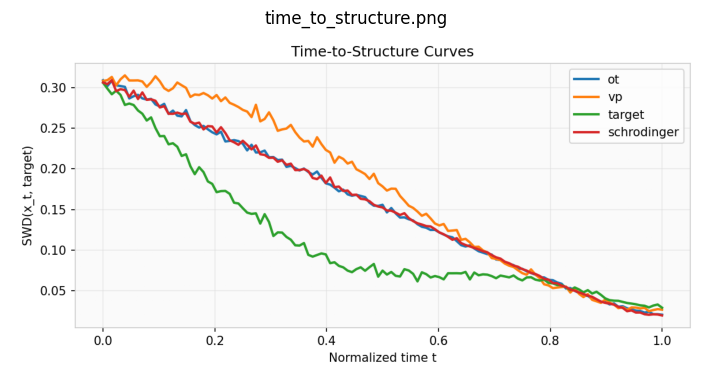

In [34]:
for name in ['time_to_structure.png']:
    p = fig_dir / name
    if p.exists():
        plt.figure(figsize=(10, 4.5))
        plt.imshow(imread(p))
        plt.axis('off')
        plt.title(name)
        plt.show()
    else:
        print('Missing figure:', p)


In [35]:
progress_auc_df = pd.DataFrame({'progress_auc_swd': results['progress_auc_swd']}).T
progress_auc_df


,ot,vp,target,schrodinger
progress_auc_swd,0.154778,0.174065,0.111864,0.155151


### Your Notes (F)
Write your interpretation here:
- Which variant has best (lowest) time-to-structure AUC?
- Is this consistent with low-NFE quality?


## 10. Global Scorecard

Compact summary across key metrics.


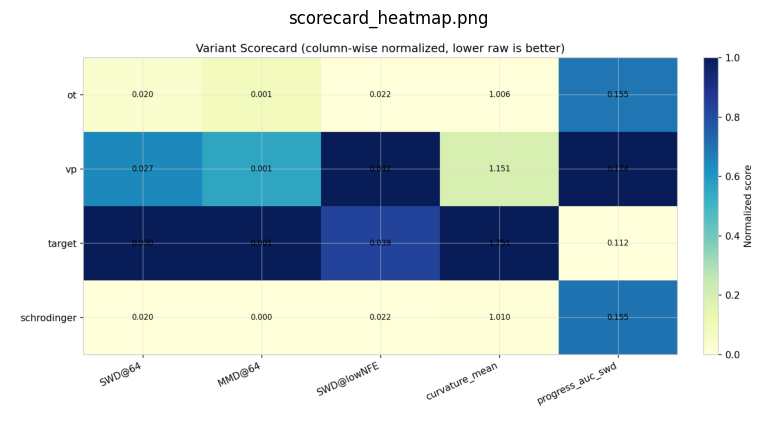

In [36]:
for name in ['scorecard_heatmap.png']:
    p = fig_dir / name
    if p.exists():
        plt.figure(figsize=(10, 5))
        plt.imshow(imread(p))
        plt.axis('off')
        plt.title(name)
        plt.show()
    else:
        print('Missing figure:', p)


In [37]:
scorecard_df = pd.DataFrame(results['scorecard']).T
scorecard_df


,SWD@64,MMD@64,SWD@lowNFE,curvature_mean,progress_auc_swd
ot,0.020488,0.000503,0.022177,1.005853,0.154778
vp,0.026546,0.000792,0.042255,1.150823,0.174065
target,0.030040,0.001068,0.038714,1.750658,0.111864
schrodinger,0.020155,0.000449,0.022103,1.010156,0.155151


## 11. Auto Gallery (All Figures)

Shows every PNG produced, so nothing is omitted.


11 figure(s):
- curvature_vs_error.png
- main_metrics_bars.png
- nfe_vs_mmd.png
- nfe_vs_swd.png
- samples_grid.png
- scorecard_heatmap.png
- solver_tradeoff_swd.png
- time_to_structure.png
- training_losses.png
- training_losses_normalized.png
- training_losses_raw.png


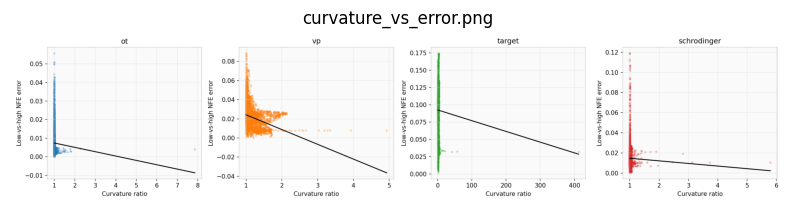

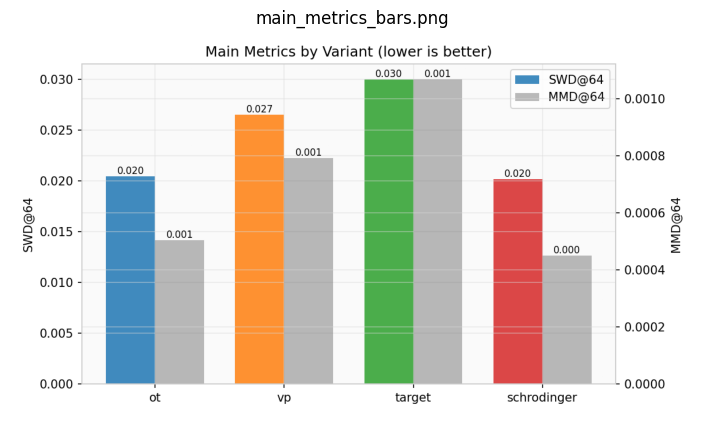

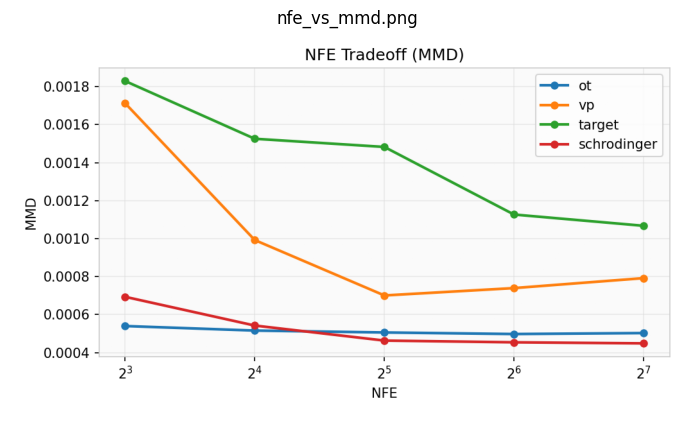

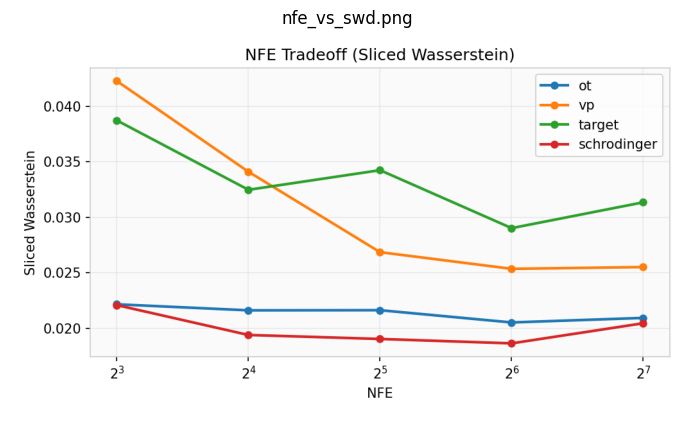

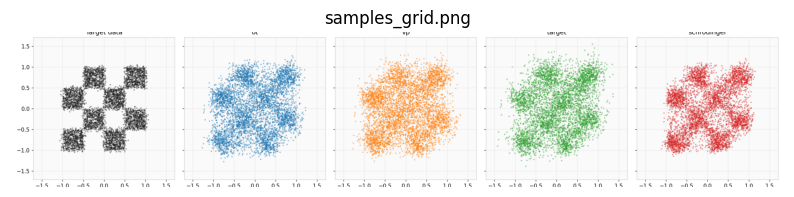

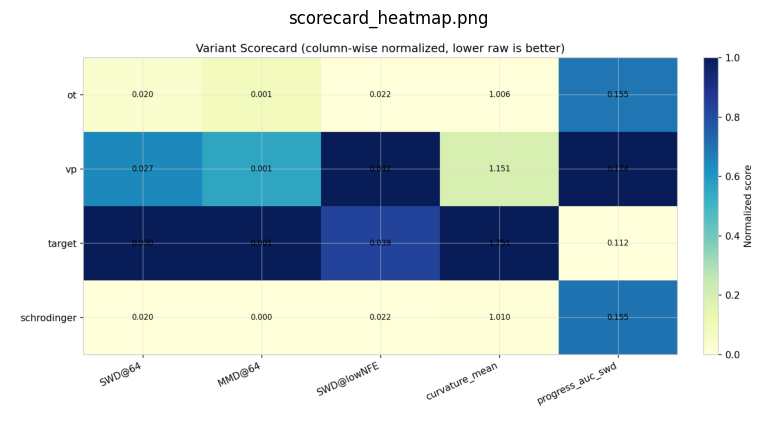

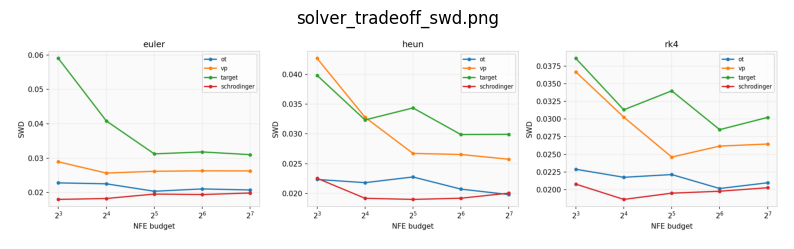

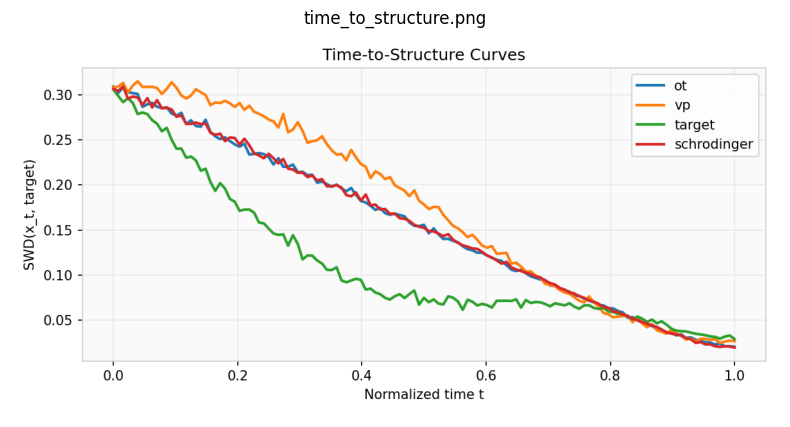

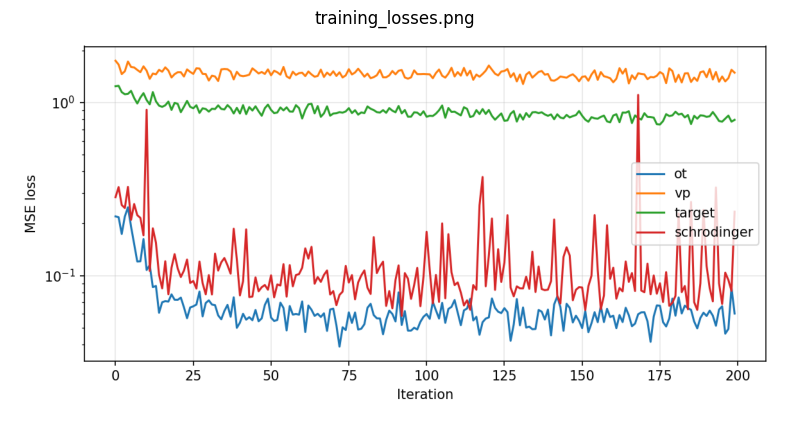

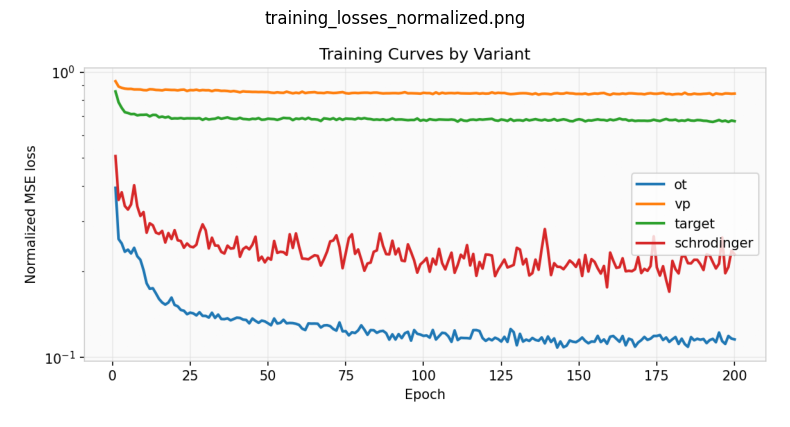

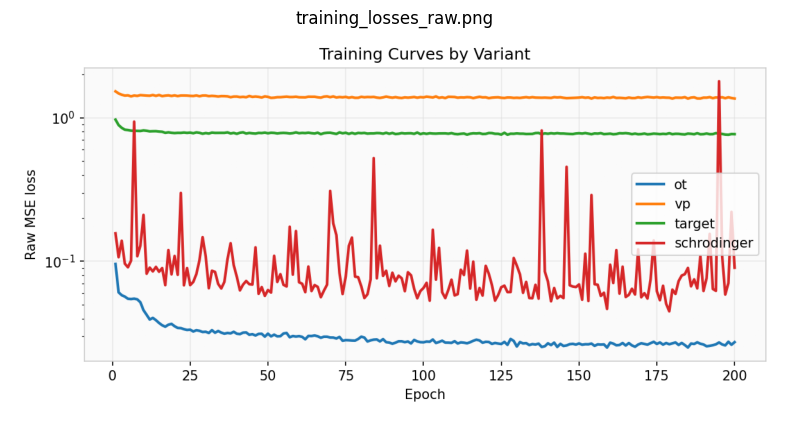

In [38]:
pngs = sorted(fig_dir.glob('*.png'))
print(f'{len(pngs)} figure(s):')
for p in pngs:
    print('-', p.name)

for p in pngs:
    plt.figure(figsize=(10, 5))
    plt.imshow(imread(p))
    plt.axis('off')
    plt.title(p.name)
    plt.show()


## 12. Optional Multi-Dataset Suite

Run this section if you want robustness across `checkerboard`, `two_moons`, and `gaussian_mixture`.
This gives stronger evidence for report/presentation.


In [39]:
from fm_project.multi_dataset import run_multi_dataset_suite


ImportError: cannot import name 'plot_multi_dataset_heatmap' from 'fm_project.plots' (/Users/sleider/ml/flow_matching_project/src/fm_project/plots.py)

In [ ]:
multi_results = run_multi_dataset_suite(
    base_config=cfg,
    datasets=['checkerboard', 'two_moons', 'gaussian_mixture'],
    output_dir=str(ROOT / 'results_multi_dataset'),
)
multi_results.keys()


In [ ]:
from matplotlib.image import imread
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

md_root = Path(ROOT) / 'results_multi_dataset'
for name in ['multi_dataset_wins.png', 'multi_dataset_heatmap.png']:
    p = md_root / 'figures' / name
    if p.exists():
        plt.figure(figsize=(11, 5))
        plt.imshow(imread(p))
        plt.axis('off')
        plt.title(name)
        plt.show()

display(pd.DataFrame(multi_results['wins']).T)


## 13. Final Conclusions (to fill)

Write your final report-style conclusions here:

1. **Reproduction claim:** ...
2. **Novel contribution claim:** ...
3. **Most important quantitative result:** ...
4. **Limitation and future work:** ...
